#**5.3.1 특성 추출 기법**

-특성 추출에 대한 예시를 진행하기에 앞서 라이브러리를 설치해야한다

`pip install opencv-python`

-OpenCV는 오픈 소스 컴퓨터 비전 라이브러리이다

In [2]:
#코드 5-12 라이브러리 호출

import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [3]:
from google.colab import files # 데이터 불러오기
file_uploaded=files.upload()   # 데이터 불러오기: chap05/data/catndog.zip 파일 선택

!unzip catanddog.zip -d catanddog/    #catanddog 폴더 만들어 압축 풀기

Saving catanddog.zip to catanddog.zip
Archive:  catanddog.zip
   creating: catanddog/test/
   creating: catanddog/test/Cat/
  inflating: catanddog/test/Cat/8100.jpg  
  inflating: catanddog/test/Cat/8101.jpg  
  inflating: catanddog/test/Cat/8102.jpg  
  inflating: catanddog/test/Cat/8103.jpg  
  inflating: catanddog/test/Cat/8104.jpg  
  inflating: catanddog/test/Cat/8105.jpg  
  inflating: catanddog/test/Cat/8106.jpg  
  inflating: catanddog/test/Cat/8107.jpg  
  inflating: catanddog/test/Cat/8108.jpg  
  inflating: catanddog/test/Cat/8109.jpg  
  inflating: catanddog/test/Cat/8110.jpg  
  inflating: catanddog/test/Cat/8111.jpg  
  inflating: catanddog/test/Cat/8112.jpg  
  inflating: catanddog/test/Cat/8113.jpg  
  inflating: catanddog/test/Cat/8114.jpg  
  inflating: catanddog/test/Cat/8115.jpg  
  inflating: catanddog/test/Cat/8116.jpg  
  inflating: catanddog/test/Cat/8117.jpg  
  inflating: catanddog/test/Cat/8118.jpg  
  inflating: catanddog/test/Cat/8119.jpg  
  inflating: cat

In [4]:
#코드 5-13 이미지 데이터 전처리 방법

data_path = 'catanddog/train/'
transform = transforms.Compose(
                [
                    transforms.Resize([256, 256]),
                    transforms.RandomResizedCrop(224),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                ])
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


####**코드 5-13에 대한 설명**

예제에서 사용할 이미지 데이터에 대한 전처리 방법을 정의해보자

1. 이미지 데이터가 위치한 경로를 지정해주고(data_path)
2. `torchvision.transform` : 이미지 데이터를 변환해 모델의 입력으로 사용할 수 있도록 변환한다

  - Resize : 이미지 크기 조정 파라미터
  - RandomResizedCrop : 이미지를 랜덤한 크기, 비율로 자른다
  -RandomHoriziontalFlip : 이미지를 랜덤하게 수평으로 뒤집는다
  -ToTensor : 이미지를 텐서로 변환

3. `datasets.IamgeFolder` : 데이터로더가 데이터를 불로올 대상과 방법(혹은 전처리)을 정의한다
  - data_path : 불러올 데이터가 위치한 경로
  - transform : 이미지 데이터에 대한 전처리

4. 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당한다.
  - train_dataset : 데이터셋 지정
  - batch_size : 한 번에 불러올 데이터양을 결정하는 배치 크기를 설정한다
  - num_workers : 데이터를 불러올 때 하위 프로세스 몇 개 사용할지 설정한다
  - shuffle : 데이터를 무작위로 섞을 것인지 정한다, True일 경우 무작위로 섞어서 랜덤으로 불러온다




In [5]:
!pip install opencv-python

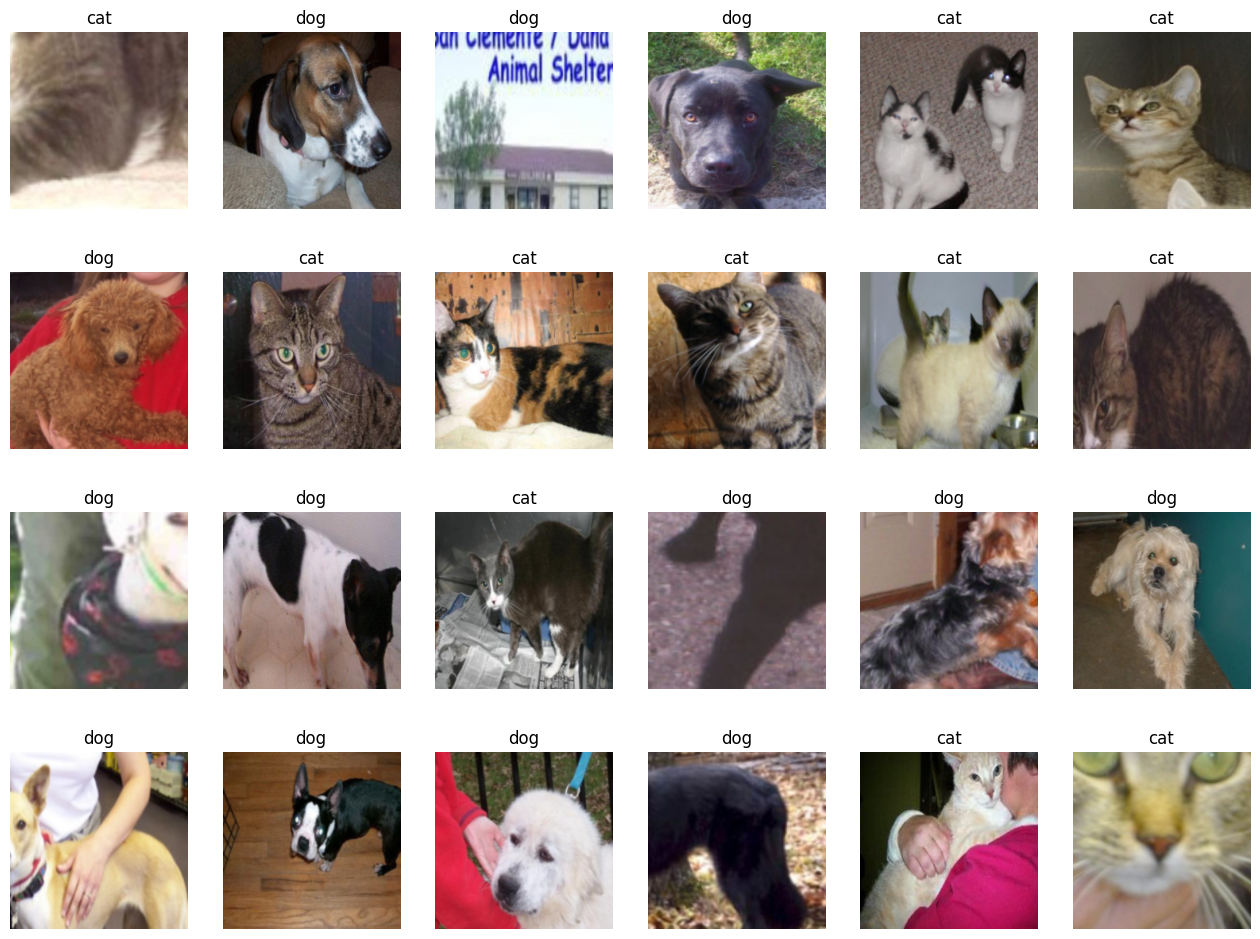

In [6]:
import numpy as np
samples, labels = next(iter(train_loader)) # Change from .next() to next()
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range(24):
    a = fig.add_subplot(4,6,i+1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

####**코드 5-14에 대한 설명**

1. 반복자를 사용하기 위해 iter(), next() 를 사용한다

  -iter() : 전달된 데이터의 반복자를 꺼내 반환
  - next() : 반복자가 다음에 출력해야할 요소를 반환


2. np.transpose : 행과 열을 바꿈으로써 행렬의 차원을 바꿔준다 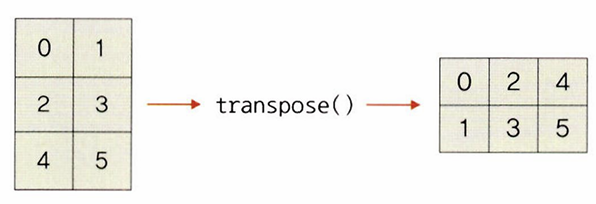



In [7]:
#코드 5-15 사전 훈련된 모델 내려받기

resnet18 = models.resnet18(pretrained=True)
#pretrained = True 는 사전 학습된 가중치를 그대로 사용한다는 의미이다

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 61.9MB/s]


In [8]:
#코드 5-16 사전 훈련된 모델의 파라미터 학습 유무 지정

def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False #----1

set_parameter_requires_grad(resnet18)

####**코드 5-16에 대한 설명**

1. 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타낸다
  - 즉 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정한다
  - 이 때 모델의 일부는 합성곱층과 풀링층을 의미한다
  - 내려받은 ResNet18은 마지막 부분에 완전연결층을 추가한다
  - 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용된다

  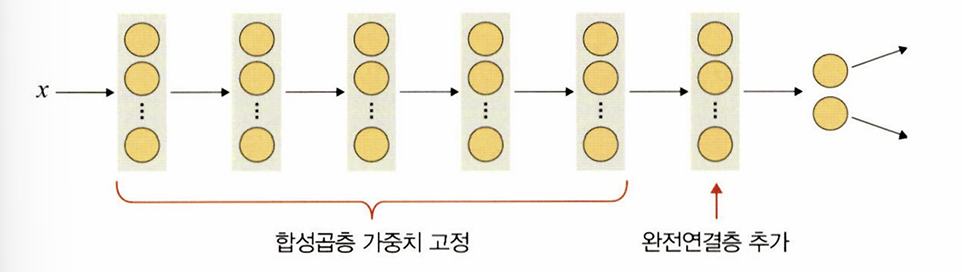

In [9]:
resnet18.fc = nn.Linear(512, 2)

for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)


#코드 5-19 모델 객체 생성 및 손실 함수 정의
model = models.resnet18(pretrained = True) #모델의 객체 생성

for param in model.parameters(): #모델의 합성곱층 가중치 고정
    param.requires_grad = False

model.fc = torch.nn.Linear(512, 2)
for param in model.fc.parameters(): #완전연결층은 학습한다
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() #손실 함수 정의
print(model)

#결과로는 내려받은 ResNet18 모델의 마지막에 완전연결층을 추가한 모델을 보여준다

fc.weight tensor([[ 0.0429, -0.0053, -0.0393,  ..., -0.0024, -0.0056, -0.0337],
        [-0.0359, -0.0213, -0.0107,  ...,  0.0201,  0.0088,  0.0256]])
fc.bias tensor([ 0.0315, -0.0252])
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kerne

In [10]:
#코드 5-20 모델 학습을 위한 함수 생성
#데이터 준비 및 네트워크 생성이 완료되었으므로 이제 모델을 학습시킨다


def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
    since = time.time()    #컴퓨터의 현재 시각을 구하는 함수
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):  #에포크만큼 반복(13)
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:  #데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()  #기울기를 0으로 설정
            outputs = model(inputs)   #순전파 학습
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()   #역전파 학습
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)  #출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
            running_corrects += torch.sum(preds == labels.data)   #출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장

        epoch_loss = running_loss / len(dataloaders.dataset)  #평균 오차 계산
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)  #평균 정확도 계산

        print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since  #실행 시간 계산
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))
    return acc_history, loss_history  #모델 정확도와 오차 반환


In [11]:
params_to_update = []
for name,param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t",name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.6168 Acc: 0.6468

Epoch 1/12
----------
Loss: 0.4483 Acc: 0.8130

Epoch 2/12
----------
Loss: 0.3092 Acc: 0.9013

Epoch 3/12
----------
Loss: 0.2753 Acc: 0.9039

Epoch 4/12
----------
Loss: 0.2801 Acc: 0.8883

Epoch 5/12
----------
Loss: 0.2371 Acc: 0.9117

Epoch 6/12
----------
Loss: 0.2593 Acc: 0.8961

Epoch 7/12
----------
Loss: 0.2123 Acc: 0.9273

Epoch 8/12
----------
Loss: 0.2247 Acc: 0.9195

Epoch 9/12
----------
Loss: 0.2219 Acc: 0.9091

Epoch 10/12
----------
Loss: 0.1906 Acc: 0.9169

Epoch 11/12
----------
Loss: 0.2107 Acc: 0.9143

Epoch 12/12
----------
Loss: 0.2037 Acc: 0.9117

Training complete in 0m 41s
Best Acc: 0.927273


코드 결과로 출력된 정확도(93%)가 상당히 높다
훈련 데이터로는 학습이 잘 되었다고 할 수 있다

이제 테스트 데이터를 이용해 모델 정확도를 측정해보는 과정을 거친다

In [15]:
test_path = 'catanddog/test/'
#교재와 path 다르게 설정해야하는거 주의하자

transform = transforms.Compose(
                [
                    transforms.Resize(224),
                    transforms.CenterCrop(224),
                    transforms.ToTensor(),
                ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [16]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('catanddog/' + '*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0
            running_corrects += preds.eq(labels).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('Acc: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:4f}'.format(best_acc))

    return acc_history

In [17]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['catanddog/00.pth', 'catanddog/01.pth', 'catanddog/02.pth', 'catanddog/03.pth', 'catanddog/04.pth', 'catanddog/05.pth', 'catanddog/06.pth', 'catanddog/07.pth', 'catanddog/08.pth', 'catanddog/09.pth', 'catanddog/10.pth', 'catanddog/11.pth', 'catanddog/12.pth']
Loading model catanddog/00.pth
Acc: 0.8163

Loading model catanddog/01.pth
Acc: 0.8980

Loading model catanddog/02.pth
Acc: 0.8878

Loading model catanddog/03.pth
Acc: 0.9286

Loading model catanddog/04.pth
Acc: 0.9184

Loading model catanddog/05.pth
Acc: 0.9184

Loading model catanddog/06.pth
Acc: 0.9184

Loading model catanddog/07.pth
Acc: 0.9388

Loading model catanddog/08.pth
Acc: 0.9082

Loading model catanddog/09.pth
Acc: 0.9286

Loading model catanddog/10.pth
Acc: 0.9184

Loading model catanddog/11.pth
Acc: 0.9082

Loading model catanddog/12.pth
Acc: 0.9388

Validation complete in 0m 8s
Best Acc: 0.938776


테스트 데이터 역시 높은 정확도를 보인다(94%)


사전 훈련된 모델을 사용해 손쉽게 모델을 학습시킬 수 있는 과정이었다

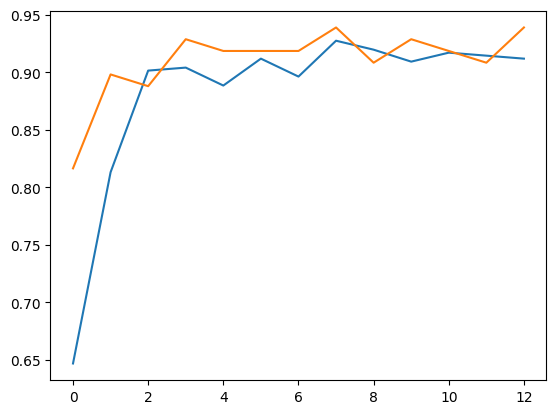

In [18]:
#모델의 학습 결과를 시각적으로 살펴보려고 한다
#코드 5-26 훈련과 테스트 데이터의 정확도를 그래프로 확인

plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

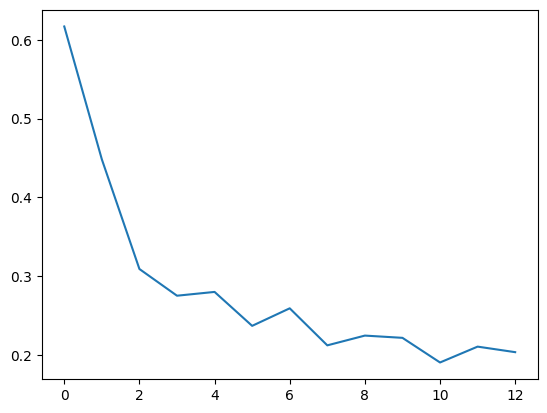

In [19]:
plt.plot(train_loss_hist)
plt.show()

In [20]:
def im_convert(tensor):
    image=tensor.clone().detach().numpy()
    image=image.transpose(1,2,0)
    image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
    image=image.clip(0,1)
    return image

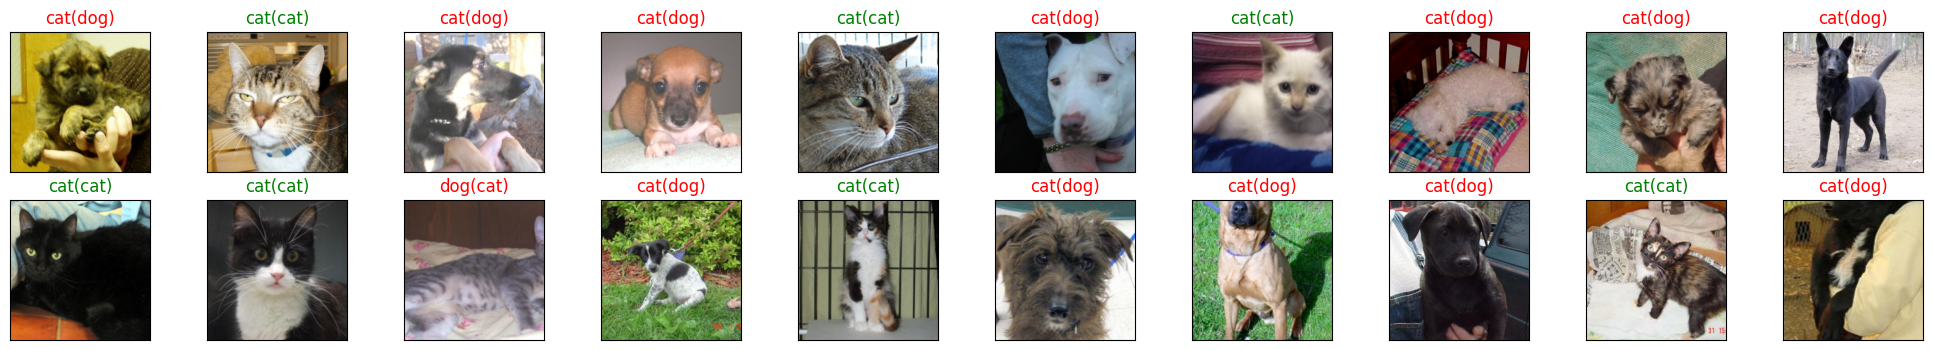

<Figure size 640x480 with 0 Axes>

In [22]:
#코드 5-29
classes = {0:'cat', 1:'dog'}

dataiter=iter(test_loader)
images,labels=next(dataiter) # Change from .next() to next()
output=model(images)
_,preds=torch.max(output,1)

fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
    plt.imshow(im_convert(images[idx]))
    # a.set_title(classes[labels[i].item()]) # 'a' and 'i' were from previous cells and need to be 'ax' and 'idx'
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

####**코드 5-29에 대한 설명**


개와 고양이에 대한 분류가 잘 이뤄지는지 확인해보았다

1. add_subplot : 한 화면에 여러 개의 이미지를 담기 위해 사용
2. classes[preds[idx].item()] : calsses로 정의된 0과 중에서 어떤 값을 갖는지 판별하겠다는 의미
3. plt.subplots_adjust : 다음 이미지같이 Figure 안에서 서브플롯의 위치를 조정할 때 사용
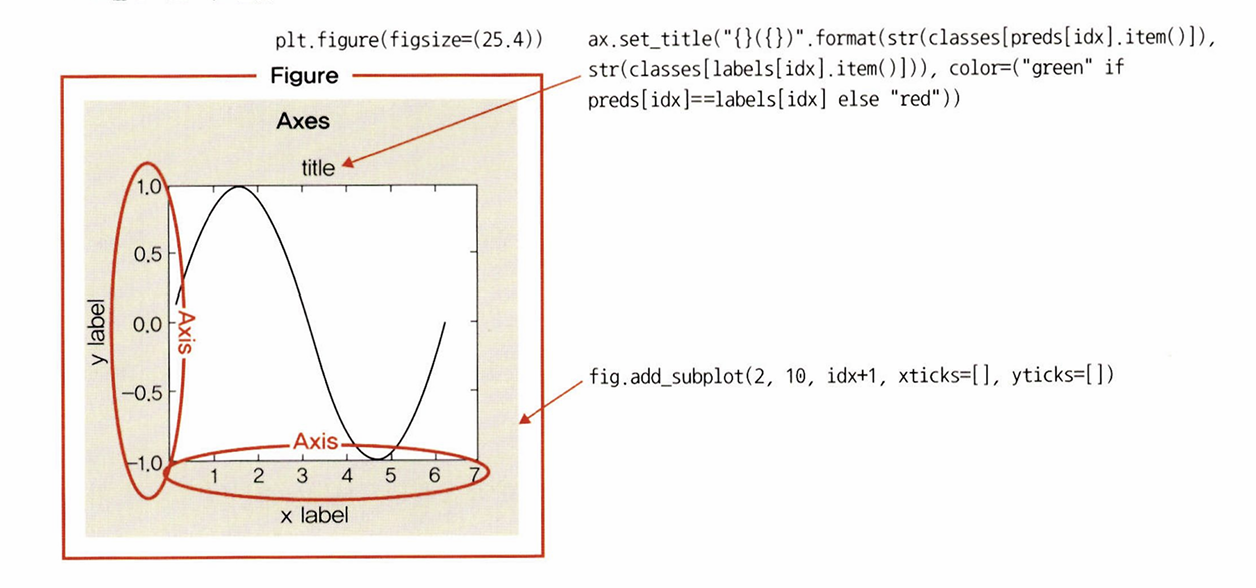